## Load an ActiveLearningLoop state from disk

During the AL loop state files are saved per iteration and at the start and end of the whole process. They store settings, history of results and other statuses during the simulation. We can load the `ActiveLearningLoop` class from those.

In [1]:
from pathlib import Path

import scm.plams as plams

from scm.active_learning import ActiveLearningAnalysis, ActiveLearningLoop, LoopResult
from scm.active_learning.tutorials import find_final_state, require_modules

In [2]:
# Set this to a specific al_final_state file to make the tutorial fully reproducible.
state_path: Path | None = None
path = find_final_state(state_path)
loop = ActiveLearningLoop.load_model(path)

## ActiveLearningAnalysis
`ActiveLearningAnalysis` is a class for convenient analysis of the finished active learning loop. It implements convenient methods for exploring the tree like structure of the `ActiveLearningLoop` class.

In [3]:
al_analysis:ActiveLearningAnalysis = loop.analysis

The main attribute of the `ActiveLearningAnalysis` is actually the `ActiveLearningLoop`. Therefore, you can prefer whether to use as "main" object the `al_analysis` or `loop` instead. We recommend to just use `loop`.

In [4]:
loop: ActiveLearningLoop = al_analysis.loop

### Analysis plots

There is a conveninet plot class in the `ActiveLearningAnalysis` that generates a collection of simple plots collected in a simgle pdf:

In [5]:
pdf_plots = loop.analysis.plot.save_to_pdf()

/home/bene/Documents/work/ALIR/Code/active_learning_workspace/active_learning/tutorials/notebooks/ALruns/20260421_152749/analysis.pdf


In [6]:
import webbrowser

# This will open the file using your default system viewer (often a browser)
webbrowser.open(str(pdf_plots))

True

### Access the log file

The results of the active learning are printed in a human-friendly format in the log file. Remember log file is supposed to be a friendly readable file for human inspection. Structured results are accessible via the state files.

For example, let's print the last few lines:

In [7]:
n_lines = 40
log_path = loop.analysis.get_logfile_path()
if log_path:
    end_of_logfile = "\n".join(log_path.read_text().splitlines()[-n_lines:])
    print(end_of_logfile)

2026-04-21 15:45:33 | INFO     | scm.active_learning.callbacks.al_state_logger               :after_accuracy      :46   - iAL:18 | Accuracy  Results
engine_id    task_id    system_id    checker_id      property    units      metric      atom_type    components       value    target    n_entries  success
-----------  ---------  -----------  --------------  ----------  ---------  --------  -----------  ------------  ----------  --------  -----------  ---------
M3GNet16     AMSMDTask  OCC=O        AMSTrajChecker  energy      eV/NAtoms  rmse               -1            -1  0.00442531       0.1            3  OK
M3GNet16     AMSMDTask  OCC=O        AMSTrajChecker  forces      eV/Ang     rmse               -1            -1  0.0956336        0.1           72  OK
2026-04-21 15:45:33 | SUCCESS  | scm.active_learning.journey_scheduler.simple_active_learning:build_results       :651  - SimpleActiveLearningJourney: Step 4 at attempt 1 SUCCESS! Because Validity AND Accuracy checks passed.
2026-04-21

Above we can easily see that there were 5 active learning steps, and the engine settings for the final trained ML potential.

Tip: You can copy-paste the lines from ``Engine MLPotential`` to ``EndEngine`` into AMSinput to use those engine settings for other production simulations in the GUI.

### Access to overview tables
The log file contains information logged in with time ordering, but sometimes it is better to see the data aggregate by the different stages of the AL loop.

In [8]:
print(loop.analysis.view_table(options="journey"))

=================================== JourneyScheduler ===================================
AMSMDTask|OCC=O -> AMSTrajChecker|AMSTrajGetter
  MD NSteps    MD NSteps - Cumulative    MD SamplingFreq    MD MaxFrames    max_attempts
-----------  ------------------------  -----------------  --------------  --------------
        100                       100                  3              33              10
        216                       316                  7              30              10
        684                      1000                 22              31              10
       2162                      3162                 72              30              10
       6838                     10000                100              68              10


In [9]:
print(loop.analysis.view_table(options="history"))

================================================ JourneyHistory ================================================
  Idx  type        step    n_steps_left    attempt  finished_msg                           finished    success
-----  --------  ------  --------------  ---------  -------------------------------------  ----------  ---------
    0  SALState       1               3          1  Validity AND Accuracy checks passed.   True        True
    1  SALState       1               3          1  Validity AND Accuracy checks passed.   True        True
    2  SALState       1               3          1  Validity AND Accuracy checks passed.   True        True
    3  SALState       1               3          1  Validity AND Accuracy checks passed.   True        True
    4  SALState       1               3          1  Validity AND Accuracy checks passed.   True        True
    5  SALState       1               3          1  Validity AND Accuracy checks passed.   True        True
    6  SALState

In [10]:
print(loop.analysis.view_table(options="summary"))

  iteration_al    n_tasks    n_systems    n_validity_checks    n_validity_success    n_frames    n_accuracy_checks    n_accuracy_success
--------------  ---------  -----------  -------------------  --------------------  ----------  -------------------  --------------------
             0          1            1                    1                     1           2                    0                     0
             1          1            1                    1                     1           2                    2                     1
             2          1            1                    1                     1           2                    2                     1
             3          1            1                    1                     1           2                    2                     1
             4          1            1                    1                     1           2                    2                     1
             5          1            1   

Adjust the screen size for tables with large amount of columns, like the validity table:

In [11]:
print(loop.analysis.view_table(options="validity"))

  iteration_al  engine_id    task_id    system_id    checker_id      property    units    per_n_atoms    metric                    atom_type    components  value_type      value    target  lower_is_better      n_entries  success
--------------  -----------  ---------  -----------  --------------  ----------  -------  -------------  ----------------------  -----------  ------------  ------------  -------  --------  -----------------  -----------  ---------
             0  UFFRef       AMSMDTask  OCC=O        AMSTrajChecker  trajectory  0-index  False          reasonable_final_frame           -1            -1  float              33        33  True                        34  OK
             1  M3GNet00     AMSMDTask  OCC=O        AMSTrajChecker  trajectory  0-index  False          reasonable_final_frame           -1            -1  float              33        33  True                        34  OK
             2  M3GNet01     AMSMDTask  OCC=O        AMSTrajChecker  trajectory  0-index  Fa

In [12]:
print(loop.analysis.view_table(options="getters"))

  iteration_al  engine_id    task_id    system_id    checker_id      getter_id        n_data
--------------  -----------  ---------  -----------  --------------  -------------  --------
             0  UFFRef       AMSMDTask  OCC=O        AMSTrajChecker  AMSTrajGetter         2
             1  M3GNet00     AMSMDTask  OCC=O        AMSTrajChecker  AMSTrajGetter         2
             2  M3GNet01     AMSMDTask  OCC=O        AMSTrajChecker  AMSTrajGetter         2
             3  M3GNet02     AMSMDTask  OCC=O        AMSTrajChecker  AMSTrajGetter         2
             4  M3GNet03     AMSMDTask  OCC=O        AMSTrajChecker  AMSTrajGetter         2
             5  M3GNet04     AMSMDTask  OCC=O        AMSTrajChecker  AMSTrajGetter         2
             6  M3GNet05     AMSMDTask  OCC=O        AMSTrajChecker  AMSTrajGetter         2
             7  M3GNet06     AMSMDTask  OCC=O        AMSTrajChecker  AMSTrajGetter         2
             8  M3GNet07     AMSMDTask  OCC=O        AMSTrajChecker  A

In [13]:
print(loop.analysis.view_table(options="accuracy"))

  iteration_al  engine_id    task_id    system_id    checker_id      property    units    per_n_atoms    metric      atom_type    components  value_type          value    target  lower_is_better      n_entries  success
--------------  -----------  ---------  -----------  --------------  ----------  -------  -------------  --------  -----------  ------------  ------------  -----------  --------  -----------------  -----------  ---------
             1  M3GNet00     AMSMDTask  OCC=O        AMSTrajChecker  energy      eV       True           rmse               -1            -1  float         0.0449189         0.1  True                         2  OK
             1  M3GNet00     AMSMDTask  OCC=O        AMSTrajChecker  forces      eV/Ang   False          rmse               -1            -1  float         1.0085            0.1  True                        48
             2  M3GNet01     AMSMDTask  OCC=O        AMSTrajChecker  energy      eV       True           rmse               -1          

In [14]:
print(loop.analysis.view_table(options="train"))

  iteration_al  trained    type          dataset                 mae    n_entries  property          r2         rmse  units
--------------  ---------  ------------  --------------  -----------  -----------  ----------  --------  -----------  -------
             0  True       ParAMSEngine  training_set    2.75151e-05            1  energy      1         2.75151e-05  eV
             0  True       ParAMSEngine  training_set    0.00364442            24  forces      0.999986  0.0046304    eV/Ang
             0  True       ParAMSEngine  validation_set  0.137878               1  energy      1         0.137878     eV
             0  True       ParAMSEngine  validation_set  0.446067              24  forces      0.266945  0.669745     eV/Ang
             1  True       ParAMSEngine  training_set    0.00315265             2  energy      1         0.00315265   eV
             1  True       ParAMSEngine  training_set    0.00768952            48  forces      0.999949  0.0100916    eV/Ang
            

In [15]:
print(loop.analysis.view_table(options="timings",add_skip=False))

  iteration_al    ACCURACY[min]    CONVERGENCE[min]    LABEL[min]    SPLIT_AND_ADD[min]    TASK[min]    TRAIN[min]
--------------  ---------------  ------------------  ------------  --------------------  -----------  ------------
             0      3.33333e-08         3.33333e-08    0.00580665           0.000158833   0.00454647   0.518432
             1      0.107336            2.19333e-05    0.00461782           0.000110817   0.104522     0.492202
             2      0.107034            1.30667e-05    0.00443972           0.000130967   0.107711     0.523996
             3      0.107334            1.01833e-05    0.00440947           8.60333e-05   0.110477     0.540961
             4      0.105901            1.07e-05       0.003913             9.325e-05     0.109701     0.550942
             5      0.109715            1.225e-05      0.00412437           0.000109067   0.113101     0.836018
             6      0.107901            1.015e-05      0.00403018           0.000107817   0.10543 

The timings table by default is viewed with skip information if certain steps got skipped.

In [16]:
print(loop.analysis.view_table(options="timings", tabulate_kwargs={"floatfmt":".2f"}))

  iteration_al  ACCURACY[min]                            CONVERGENCE[min]                           LABEL[min]  SPLIT_AND_ADD[min]        TASK[min]  TRAIN[min]
--------------  ---------------------------------------  ---------------------------------------  ------------  ----------------------  -----------  --------------------------------------
             0  SkipIf: start engine is not finetunable  SkipIf: start engine is not finetunable          0.01  0.00015883333333333334         0.00  0.5184323
             1  0.10733636666666667                      2.1933333333333332e-05                           0.00  0.00011081666666666667         0.10  0.49220216666666666
             2  0.10703371666666667                      1.3066666666666666e-05                           0.00  0.00013096666666666666         0.11  0.5239957
             3  0.10733355000000001                      1.0183333333333333e-05                           0.00  8.603333333333333e-05          0.11  0.54096148333333

## Access the MD trajectories

### Run amsmovie explorer

Explore all the md trajectories with: 
```bash
uvx marimo run active_learning/scripts/amsmovie_browser.py --sandbox
```

And then in choose the 
- pattern: `*/M3GNet*AMSMDTask/ams.rkf`
- path: as shown below.

In [17]:
log_path.parent

PosixPath('/home/bene/Documents/work/ALIR/Code/active_learning_workspace/active_learning/tutorials/notebooks/ALruns/20260421_152749')

### Inspect one trajectory and frame getter from journey history

To access to the MD trajectories we can look into the `IterationState` class. This class store per AL iteration results of each step. In this case we can look at in via the loop directly.

In [18]:
# utility method

import pandas as pd
import plotly.express as px


def get_df_view(dataset, x = 'History%Step', y = 'History%EngineEnergy', series="on-the-fly"):
    df_clean = pd.DataFrame({
        x: [rr.properties[x] for rr in dataset],
        y: [rr.properties[y] for rr in dataset],
        "Series": series,
    })
    return df_clean, x, y, series


In [19]:
from scm.active_learning.loop.iteration_state import IterationState

last_iteration_results:IterationState = loop.result.iterations[-1]

In [20]:
assert last_iteration_results.task_results is not None
ds = last_iteration_results.task_results.validity_get_results[0].getter_results.dataset
ds.out_properties

[PropertyInfo(name='History%Energy', unit=None, shape=(1,), description=''),
 PropertyInfo(name='History%Step', unit=None, shape=(1,), description=''),
 PropertyInfo(name='History%EngineEnergy', unit=None, shape=(1,), description=''),
 PropertyInfo(name='MDHistory%NHCTstat1Temperature', unit='Kelvin', shape=(1,), description=''),
 PropertyInfo(name='MDHistory%Velocities', unit='bohr/fs', shape=('nAtoms', 3), description=''),
 PropertyInfo(name='MDHistory%PotentialEnergy', unit='Hartree', shape=(1,), description=''),
 PropertyInfo(name='MDHistory%TotalEnergy', unit='Hartree', shape=(1,), description=''),
 PropertyInfo(name='MDHistory%NHCTstat1Energy', unit='Hartree', shape=(1,), description=''),
 PropertyInfo(name='MDHistory%Temperature', unit='Kelvin', shape=(1,), description=''),
 PropertyInfo(name='MDHistory%KineticEnergy', unit='Hartree', shape=(1,), description=''),
 PropertyInfo(name='MDHistory%Time', unit='fs', shape=(1,), description=''),
 PropertyInfo(name='MDHistory%Step', uni

In [21]:
print(last_iteration_results.task_results.validity_get_results[0].validity_results_table())

engine_id    task_id    system_id    checker_id      property    units    per_n_atoms    metric                    atom_type    components  value_type      value    target  lower_is_better      n_entries  success
-----------  ---------  -----------  --------------  ----------  -------  -------------  ----------------------  -----------  ------------  ------------  -------  --------  -----------------  -----------  ---------
M3GNet16     AMSMDTask  OCC=O        AMSTrajChecker  trajectory  0-index  False          reasonable_final_frame           -1            -1  float             194       194  True                       195  OK


In [22]:
ds_clean = ds.restore_original()

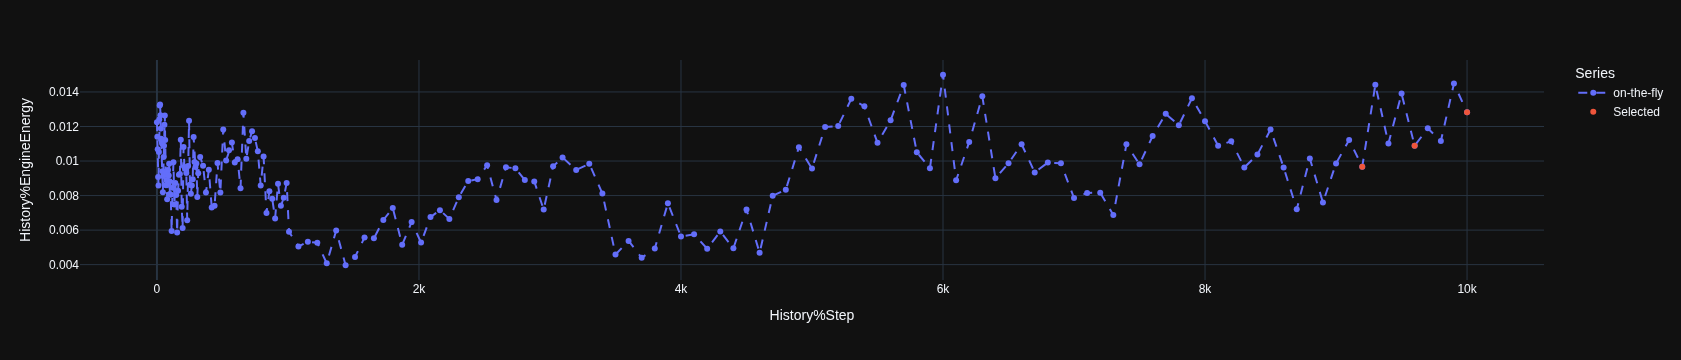

In [23]:
df_clean, x,y,s_0  = get_df_view(ds.restore_original())
df_selected, x,y,s_1  = get_df_view(ds, series="Selected")

df = pd.concat([df_clean, df_selected], ignore_index=True)

fig = px.line(
    df,
    x=x,
    y=y,
    color="Series",
    markers=True,
).update_traces(
    selector=dict(name=s_1),
    mode="markers"
).update_traces(
    selector=dict(name=s_0),
    line=dict(dash="dash")
).update_layout(template="plotly_dark")

fig.show()

## AL result

In [24]:
loop_result:LoopResult=loop.result
loop_result.model_dump().keys()

dict_keys(['iterations', 'final_engine', 'exit_message'])

In [25]:
loop.result.exit_message

'ActiveLearningLoop FINISHED! At iteration 18 because AL stopped: CONVERGED'

### Access the ParAMS training results


In [26]:
from scm.active_learning.engines import ParAMSEngine

final_engine = loop.result.final_engine
params_results_dir = None
if isinstance(final_engine, ParAMSEngine):
    params_results_dir = Path(final_engine.job_path) / "results"
    print(params_results_dir)

/home/bene/Documents/work/ALIR/Code/active_learning_workspace/active_learning/tutorials/notebooks/ALruns/20260421_152749/iter_16/ParAMSTrainer/results


**Open it in the ParAMS GUI** (uncomment the following line):

In [27]:
# !params -gui "{params_results_dir}"

The ParAMS GUI is the best way to quickly get an overview of the data sets and results.

However, it can also be useful to **access results from Python**. 

The details of the ParAMSJob and ParAMSResults classes are shown in the ParAMS Python examples, here we just provide a quick example:

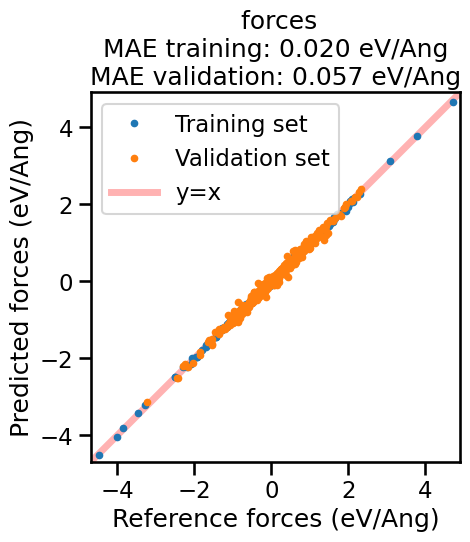

In [28]:
import contextlib

with contextlib.suppress(ModuleNotFoundError):
    from scm.params import ParAMSJob
    if params_results_dir is not None:
        params_job:ParAMSJob = ParAMSJob.load_external(params_results_dir) # pyright: ignore[reportAssignmentType]
        params_job.results.plot_simple_correlation("forces", source="best")

If you want to access individual data entries or the MAE in Python, you can use the ``params_job.results.get_data_set_evaluator()`` method. See the ParAMS DataSetEvaluator documentation for details.

### Access the production engine settings

The engine settings used for production simulation can be accessed from the ParAMS job:

In [29]:
engine_settings = final_engine.settings if isinstance(final_engine, ParAMSEngine) else None
print(plams.AMSJob(settings=engine_settings).get_input())


Engine MLPotential
  Backend M3GNet
  MLDistanceUnit angstrom
  MLEnergyUnit eV
  Model Custom
  ParameterDir /home/bene/Documents/work/ALIR/Code/active_learning_workspace/active_learning/tutorials/notebooks/ALruns/20260421_152749/iter_16/ParAMSTrainer/results/optimization/m3gnet/m3gnet
EndEngine




### Access the reference data

The reference data folder can be accessed from the corresponding `params_data` directory:

In [30]:
loop.splitting.dataset

ASEMolData(len=39, properties=['energy', 'forces'], transforms=[] at 0x753693626d50)

## Next Step

Take a look at the results and inspect the simulation:

- __[sal-3-single_molecule_production_simulation.ipynb](sal-3-single_molecule_production_simulation.ipynb)__